In [38]:
import pandas as pd

# NE PAS copier-coller depuis un document Word
df = pd.read_csv('C:/Users/pc/Downloads/Fusion_3.csv', low_memory=False)



print(df.head())



   US_ORDRE  A7  B0                  BN                     B1        B2  B4  \
0       303   5  10  ابراهيم ولد القاسم  Aucun lien de parenté  Masculin  40   
1       874   9   4      محمد لمين احمد  Aucun lien de parenté  Masculin   9   
2       799   1   2           أحمد حمدي  Aucun lien de parenté  Masculin  29   
3       135   2   8     النكه ولد لحبيب  Aucun lien de parenté  Masculin  13   
4       733   2  13               adama  Aucun lien de parenté  Masculin  10   

                    B5  B5ACJ1  B5ACJ2  ...  E10_CM  statut_CM ocu_CM gsecm  \
0  Marié(e) (monogame)     0.0     NaN  ...     NaN        NaN    NaN   NaN   
1                  NaN     NaN     NaN  ...     NaN        NaN    NaN   NaN   
2           Divorcé(e)     NaN     NaN  ...     NaN        NaN    NaN   NaN   
3      Jamais marié(e)     NaN     NaN  ...     NaN        NaN    NaN   NaN   
4      Jamais marié(e)     NaN     NaN  ...     NaN        NaN    NaN   NaN   

  me_CM  h_me_CM type_emploi  scole    age_c

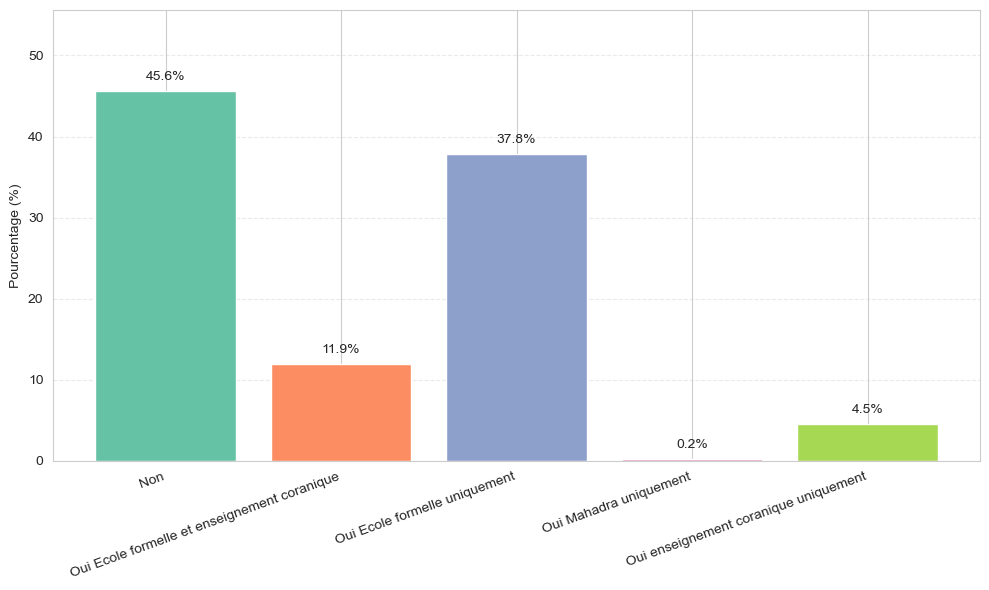

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 S'assurer que B4 est bien numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer les filles âgées de 14 à 19 ans
df_filles = df[(df['B2'] == 'Féminin') & (df['B4'] >= 12) & (df['B4'] <= 23)].copy()

# 🔹 Regrouper les effectifs pondérés
repartition = df_filles.groupby('C5')['ipond'].sum()

# 🔹 Calculer les pourcentages
total = repartition.sum()
repartition_pct = (repartition / total * 100).round(1)

# 🔹 Générer les couleurs
labels = repartition_pct.index.astype(str)
values = repartition_pct.values
colors = sns.color_palette("Set2", len(values))

# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

# 🔹 Ajouter les % sur les barres
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

# 🔹 Mise en forme finale
# ax.set_title("Répartition en % des types d’enseignement fréquenté en 2019/2020 (filles 14–19 ans)", fontsize=13, weight='bold')
# ax.set_xlabel("Réponse")
ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, max(values) + 10)
plt.xticks(rotation=20, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


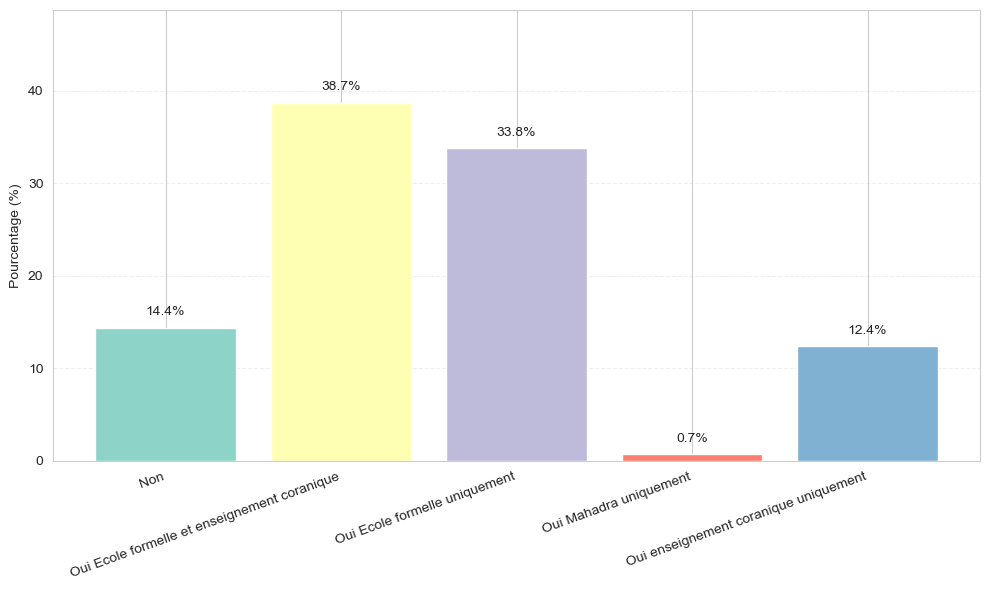

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Filtrer les filles âgées de 14 à 23 ans
df_filles = df[(df['B2'] == 'Féminin') & (df['B4'] >= 12) & (df['B4'] <= 23)].copy()

# 🔹 Calculer les effectifs pondérés par modalité de C2
repartition = df_filles.groupby('C2')['ipond'].sum()

# 🔹 Convertir en pourcentages
total = repartition.sum()
repartition_pct = (repartition / total * 100).round(1)

# 🔹 Préparer données pour affichage
labels = repartition_pct.index.astype(str)
values = repartition_pct.values
colors = sns.color_palette("Set3", len(values))

# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

# 🔹 Ajouter les % sur les barres
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

# 🔹 Mise en forme finale
# ax.set_title("Répartition en % des types d'enseignement déjà fréquenté (filles 14–19 ans)", fontsize=13, weight='bold')
# ax.set_xlabel("Réponse")
ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, max(values) + 10)
plt.xticks(rotation=20, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


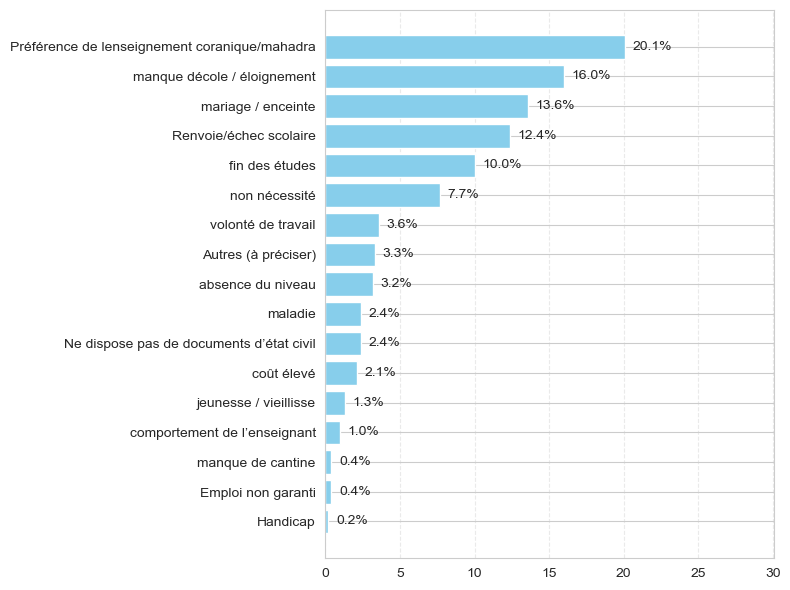

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Filtrage femmes non scolarisées âgées de 14 à 23 ans
non_freq = df[
    (df['B2'] == 'Féminin') &
    (df['B4'] >= 12) &
    (df['B4'] <= 23) &
    (df['scole'] == 1) &
    (df['raison_non_freq'].notna())
].copy()

# 🔹 Regrouper les raisons pondérées
table = non_freq.groupby('raison_non_freq')['ipond'].sum()
table_percent = (table / table.sum() * 100).round(1).sort_values()

# 🔹 Graphique à barres horizontales
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(table_percent.index, table_percent.values, color='skyblue')

# Ajouter les pourcentages à droite
for i, v in enumerate(table_percent.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10)

# Mise en forme
# ax.set_title("Raisons de non fréquentation scolaire chez les filles", fontsize=13, weight='bold')
# ax.set_xlabel("Pourcentage pondéré (%)")
ax.set_xlim(0, table_percent.max() + 10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


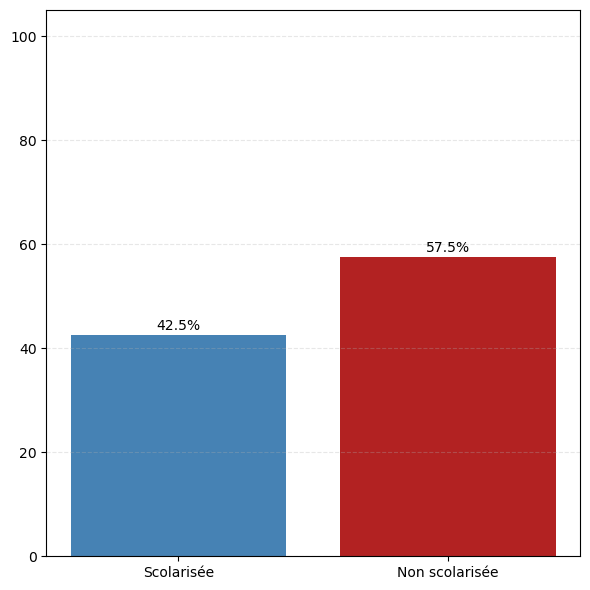

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 S'assurer que B4 est numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer les filles âgées de 12 à 23 ans avec données valides
df_filles = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(12, 23)) &
    df['scole'].notna() &
    df['ipond'].notna()
].copy()

# 🔹 Regrouper les effectifs pondérés selon le statut scole
table = df_filles.groupby('scole')['ipond'].sum()
table = table.rename({0: 'Scolarisée', 1: 'Non scolarisée'})
table_percent = (table / table.sum() * 100).round(1)

# ✅ Tracer le graphique avec taille réduite
fig, ax = plt.subplots(figsize=(6, 6))  # Taille plus petite
bars = ax.bar(table_percent.index, table_percent.values, color=['#4682B4', '#B22222'])

# 🔹 Ajouter les pourcentages
for i, v in enumerate(table_percent.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

# 🔹 Mise en forme
# ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, 105)
# ax.set_title("Taux de scolarisation des filles (12–23 ans)", fontsize=12, weight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


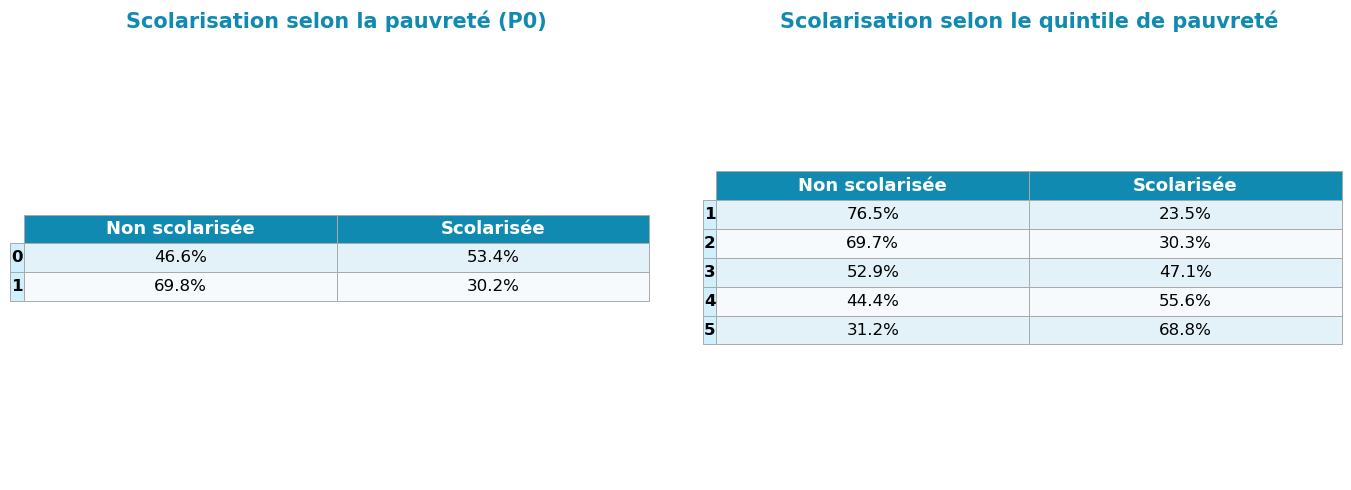

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ S'assurer que B4 est bien numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer les filles âgées de 14 à 23 ans avec données valides
df_filles = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(14, 19)) &
    (df['scole'].notna()) &
    (df['ipond'].notna())
].copy()

# 🔹 Fonction pour générer un tableau pondéré % stylisé
def make_table(variable):
    table = pd.crosstab(
        index=df_filles[variable],
        columns=df_filles['scole'].map({0: 'Scolarisée', 1: 'Non scolarisée'}),
        values=df_filles['ipond'],
        aggfunc='sum',
        normalize='index'
    ) * 100
    return table.fillna(0).round(1).astype(str) + '%'

# 🔹 Générer les tableaux
table_p0_str = make_table('P0')
table_quint_str = make_table('quintile')

# 🔹 Couleurs harmonieuses
header_color = '#118ab2'               # bleu profond stylé
index_color = '#d0f0fd'                # bleu très clair pour les lignes
row_colors = ['#f6fafd', '#e3f2f9']    # alternance lignes
border_color = '#a9a9a9'               # gris doux

# 🔹 Créer la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.axis('off')
ax2.axis('off')

# 🔹 Tableau 1 – P0
ax1.set_title("Scolarisation selon la pauvreté (P0)", fontsize=15, weight='bold', color=header_color)
t1 = ax1.table(
    cellText=table_p0_str.values,
    rowLabels=table_p0_str.index,
    colLabels=table_p0_str.columns,
    loc='center',
    cellLoc='center'
)
t1.auto_set_font_size(False)
t1.set_fontsize(12)
t1.scale(1.5, 1.5)

# 🔹 Tableau 2 – Quintile
ax2.set_title("Scolarisation selon le quintile de pauvreté", fontsize=15, weight='bold', color=header_color)
t2 = ax2.table(
    cellText=table_quint_str.values,
    rowLabels=table_quint_str.index,
    colLabels=table_quint_str.columns,
    loc='center',
    cellLoc='center'
)
t2.auto_set_font_size(False)
t2.set_fontsize(12)
t2.scale(1.5, 1.5)

# 🔹 Styliser cellules
for table in [t1, t2]:
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # en-têtes
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', weight='bold', fontsize=13)
        elif col == -1:  # index
            cell.set_facecolor(index_color)
            cell.set_text_props(weight='bold')
        else:  # lignes zébrées
            cell.set_facecolor(row_colors[row % 2])
        cell.set_linewidth(0.7)
        cell.set_edgecolor(border_color)

# 🔹 Affichage final
plt.tight_layout()
plt.show()


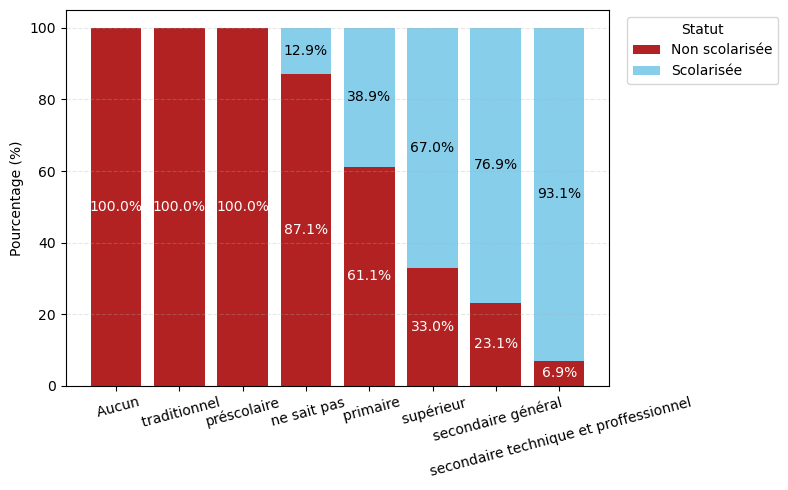

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Assurer que B4 est numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer les femmes âgées de 14 à 23 ans
femmes = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(12, 23)) &
    df['scole'].notna() &
    df['ipond'].notna() &
    df['nivcm'].notna()
].copy()

# 🔹 Mapper la variable 'scole'
femmes['scolarisation'] = femmes['scole'].map({0: 'Scolarisée', 1: 'Non scolarisée'})

# 🔹 Créer le tableau croisé pondéré (en %)
table = pd.crosstab(
    index=femmes['nivcm'],  # statut matrimonial
    columns=femmes['scolarisation'],
    values=femmes['ipond'],
    aggfunc='sum',
    normalize='index'
) * 100

table = table.fillna(0).round(1)
table = table.sort_values(by='Non scolarisée', ascending=False)  # ✅ Tri décroissant
# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(8, 5))

# ✅ Couleurs : Non scolarisée (rouge foncé) en bas, Scolarisée (bleu clair) au-dessus
colors = {
    'Non scolarisée': '#B22222',  # rouge foncé (inchangé)
    'Scolarisée': 'skyblue'       # SteelBlue : bleu équilibré
}

# 🔹 Barres empilées
bar_non = ax.bar(table.index, table['Non scolarisée'], label='Non scolarisée', color=colors['Non scolarisée'])
bar_scol = ax.bar(table.index, table['Scolarisée'], bottom=table['Non scolarisée'], label='Scolarisée', color=colors['Scolarisée'])

# 🔹 Ajouter les % sur les segments
for i, label in enumerate(table.index):
    non_pct = table.loc[label, 'Non scolarisée']
    scol_pct = table.loc[label, 'Scolarisée']
    
    if non_pct > 0:
        ax.text(i, non_pct / 2, f"{non_pct:.1f}%", ha='center', va='center', fontsize=10, color='white')
    if scol_pct > 0:
        ax.text(i, non_pct + scol_pct / 2, f"{scol_pct:.1f}%", ha='center', va='center', fontsize=10)

# 🔹 Mise en forme finale
# ax.set_title("Scolarisation selon le statut matrimonial", fontsize=13, weight='bold')
ax.set_ylabel("Pourcentage (%)")
# ax.set_xlabel("Statut matrimonial")
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelrotation=15)
ax.legend(title="Statut", loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
df.head()
print(df['B2'].head(600))


0      Féminin
1      Féminin
2      Féminin
3      Féminin
4      Féminin
        ...   
595    Féminin
596    Féminin
597    Féminin
598    Féminin
599    Féminin
Name: B2, Length: 600, dtype: object


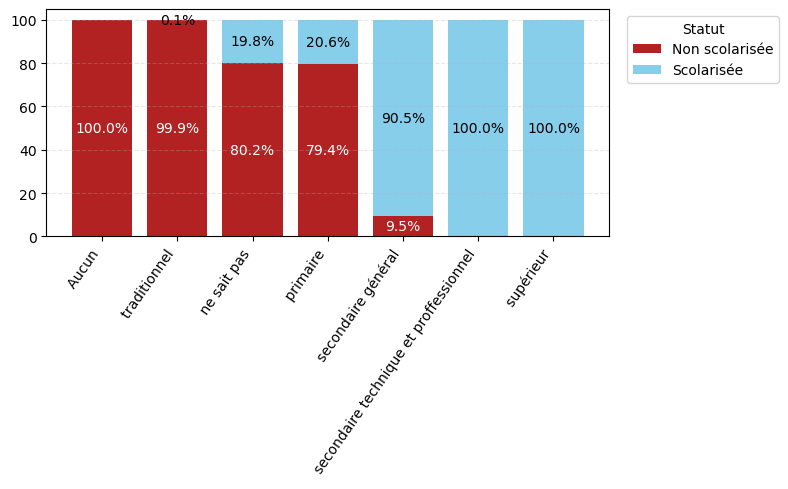

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Assurer que B4 est numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer les femmes âgées de 14 à 23 ans
femmes = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(14, 19)) &
    df['scole'].notna() &
    df['ipond'].notna() &
    df['nivcm'].notna()
].copy()

# 🔹 Mapper la variable 'scole'
femmes['scolarisation'] = femmes['scole'].map({0: 'Scolarisée', 1: 'Non scolarisée'})

# 🔹 Créer le tableau croisé pondéré (en %)
table = pd.crosstab(
    index=femmes['nivcm'],  # statut matrimonial
    columns=femmes['scolarisation'],
    values=femmes['ipond'],
    aggfunc='sum',
    normalize='index'
) * 100

table = table.fillna(0).round(1)
table = table.sort_values(by='Non scolarisée', ascending=False)  # ✅ Tri décroissant
# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(8, 5))

# ✅ Couleurs : Non scolarisée (rouge foncé) en bas, Scolarisée (bleu clair) au-dessus
colors = {
    'Non scolarisée': '#B22222',  # rouge foncé (inchangé)
    'Scolarisée': 'skyblue'       # SteelBlue : bleu équilibré
}

# 🔹 Barres empilées
bar_non = ax.bar(table.index, table['Non scolarisée'], label='Non scolarisée', color=colors['Non scolarisée'])
bar_scol = ax.bar(table.index, table['Scolarisée'], bottom=table['Non scolarisée'], label='Scolarisée', color=colors['Scolarisée'])

# 🔹 Ajouter les % sur les segments
for i, label in enumerate(table.index):
    non_pct = table.loc[label, 'Non scolarisée']
    scol_pct = table.loc[label, 'Scolarisée']
    
    if non_pct > 0:
        ax.text(i, non_pct / 2, f"{non_pct:.1f}%", ha='center', va='center', fontsize=10, color='white')
    if scol_pct > 0:
        ax.text(i, non_pct + scol_pct / 2, f"{scol_pct:.1f}%", ha='center', va='center', fontsize=10)

# 🔹 Mise en forme finale
# ax.set_title("Scolarisation selon le groupe socioéconomique du chef de menage", fontsize=13, weight='bold')
# ax.set_ylabel("Pourcentage (%)")
# ax.set_xlabel("groupe socioéconomique")
ax.set_ylim(0, 105)
# ax.tick_params(axis='x', labelrotation=55)
ax.set_xticks(range(len(table.index)))
ax.set_xticklabels(table.index, rotation=55, ha='right')

ax.legend(title="Statut", loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


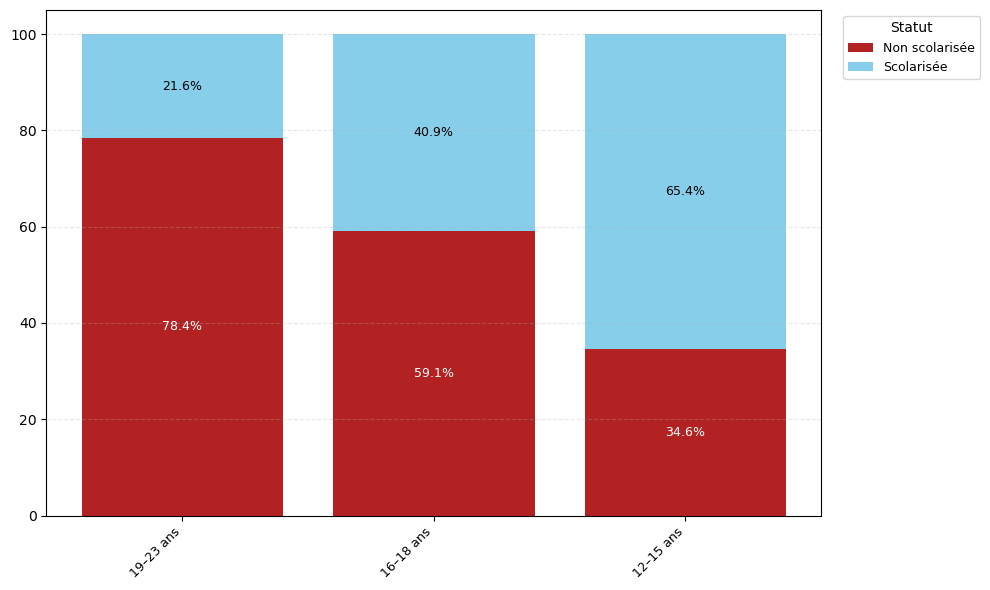

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 S'assurer que B4 est bien numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer : filles âgées de 12 à 23 ans avec variables valides
femmes = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(12, 23)) &
    (df['scole'].notna()) &
    (df['ipond'].notna()) &
    (df['age_cat'].notna())
].copy()

# 🔹 Mapper la scolarisation
femmes['scolarisation'] = femmes['scole'].map({0: 'Scolarisée', 1: 'Non scolarisée'})

# 🔹 Table croisée pondérée
table = pd.crosstab(
    index=femmes['age_cat'],
    columns=femmes['scolarisation'],
    values=femmes['ipond'],
    aggfunc='sum',
    normalize='index'
) * 100

# 🔹 Assurer que les deux colonnes existent
for col in ['Scolarisée', 'Non scolarisée']:
    if col not in table.columns:
        table[col] = 0

# 🔹 Nettoyage et tri
table = table[['Non scolarisée', 'Scolarisée']].fillna(0).round(1)
table = table.sort_values(by='Non scolarisée', ascending=False)

# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Non scolarisée': '#B22222',
    'Scolarisée': 'skyblue'
}

bar_non = ax.bar(table.index, table['Non scolarisée'], label='Non scolarisée', color=colors['Non scolarisée'])
bar_scol = ax.bar(table.index, table['Scolarisée'], bottom=table['Non scolarisée'], label='Scolarisée', color=colors['Scolarisée'])

# 🔹 Ajouter les étiquettes de % sur les segments
for i, label in enumerate(table.index):
    non_pct = table.loc[label, 'Non scolarisée']
    scol_pct = table.loc[label, 'Scolarisée']
    if non_pct > 0:
        ax.text(i, non_pct / 2, f"{non_pct:.1f}%", ha='center', va='center', fontsize=9, color='white')
    if scol_pct > 0:
        ax.text(i, non_pct + scol_pct / 2, f"{scol_pct:.1f}%", ha='center', va='center', fontsize=9)

# 🔹 Mise en forme
ax.set_ylim(0, 105)
ax.set_xticks(range(len(table.index)))
ax.set_xticklabels(table.index, rotation=45, ha='right', fontsize=9)
ax.legend(title="Statut", loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


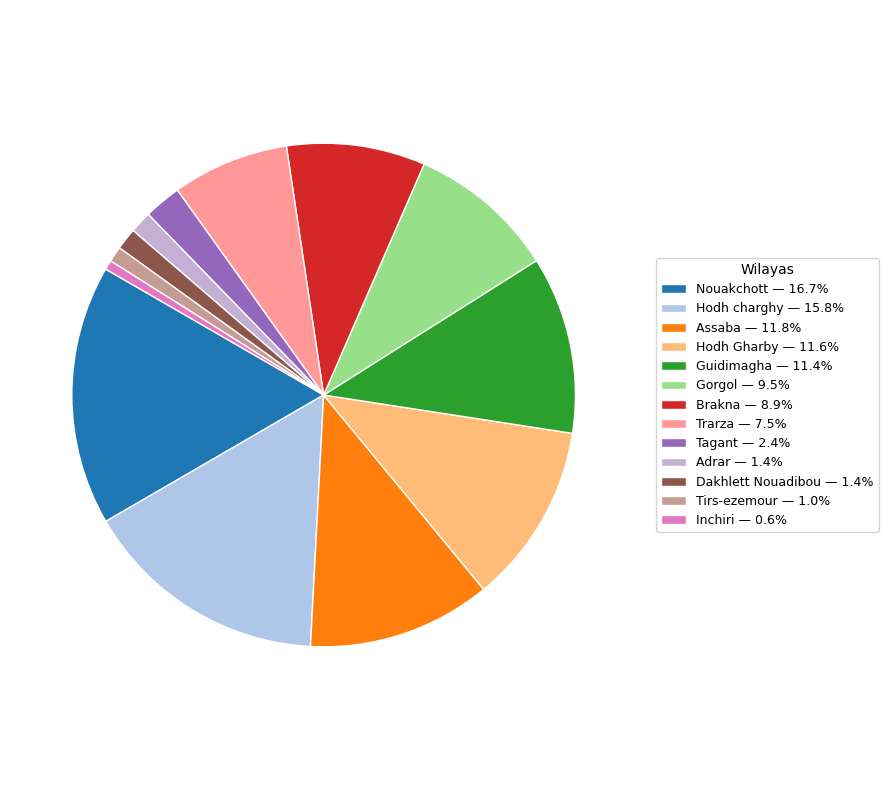

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Filtrer les filles non scolarisées âgées de 14 à 23 ans
femmes_ns = df[
    (df['B2'] == 'Féminin') &
    (df['B4'].between(14, 19)) &
    (df['scole'] == 1) &
    (df['wilaya'].notna()) &
    (df['ipond'].notna())
].copy()

# 🔹 Pondération : somme ipond par wilaya
total_par_wilaya = femmes_ns.groupby('wilaya')['ipond'].sum()
repartition = (total_par_wilaya / total_par_wilaya.sum() * 100).round(1).sort_values(ascending=False)

# 🔹 Palette esthétique (Tab20, plus vive)
colors = plt.cm.tab20.colors[:len(repartition)]

# 🔹 Tracer le diagramme circulaire
fig, ax = plt.subplots(figsize=(9, 8))
wedges, _ = ax.pie(
    repartition.values,
    startangle=150,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    radius=1.1
)

# 🔹 Légende à droite avec % intégrés
labels_legende = [f"{wilaya} — {pct:.1f}%" for wilaya, pct in zip(repartition.index, repartition.values)]

ax.legend(
    wedges,
    labels_legende,
    title="Wilayas",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# 🔹 Titre principal
# ax.set_title("Répartition des filles non scolarisées par wilaya", fontsize=14, weight='bold', pad=20)
ax.axis('equal')  # Cercle parfait

plt.tight_layout()
plt.show()


C:\Users\pc\AppData\Local\Temp\ipykernel_20712\3668744229.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tableau = df_filles.pivot_table(index='tranche_age', columns='scole', aggfunc='size', fill_value=0)


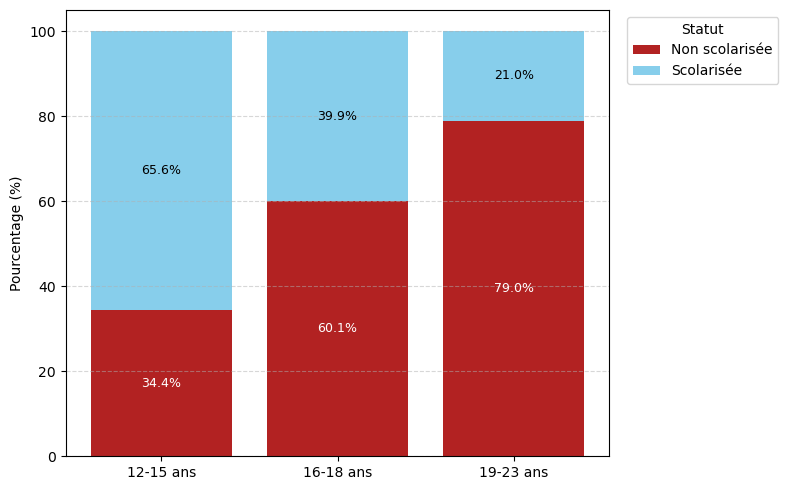

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Filtrer filles âgées de 12 à 23 ans
df_filles = df[(df['B2'] == 'Féminin') & (df['B4'].between(12, 23))].copy()

# 🔹 Créer les tranches d'âge
# bins = [11, 15, 18, 23]
# labels = ['12-15 ans', '16-18 ans', '19-23 ans']
# df_filles['tranche_age'] = pd.cut(df_filles['B4'], bins=bins, labels=labels, right=True)

# 🔹 Tableau croisé : nombre de filles par tranche d’âge et statut scolaire
tableau = df_filles.pivot_table(index='tranche_age', columns='scole', aggfunc='size', fill_value=0)
tableau = tableau.rename(columns={0: 'Scolarisée', 1: 'Non scolarisée'})

# 🔹 Ajouter les colonnes manquantes si besoin
for col in ['Scolarisée', 'Non scolarisée']:
    if col not in tableau.columns:
        tableau[col] = 0

# 🔹 Réorganiser l'ordre des colonnes
tableau = tableau[['Non scolarisée', 'Scolarisée']]

# 🔹 Calcul des pourcentages
tableau_pct = tableau.div(tableau.sum(axis=1), axis=0) * 100
tableau_pct = tableau_pct.fillna(0).round(1)

# 🔹 Tracer le graphique à barres empilées
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#B22222', 'skyblue']

bar1 = ax.bar(tableau_pct.index, tableau_pct['Non scolarisée'], color=colors[0], label='Non scolarisée')
bar2 = ax.bar(tableau_pct.index, tableau_pct['Scolarisée'], bottom=tableau_pct['Non scolarisée'], color=colors[1], label='Scolarisée')

# 🔹 Ajouter les % sur les barres
for i, label in enumerate(tableau_pct.index):
    non = tableau_pct.loc[label, 'Non scolarisée']
    scol = tableau_pct.loc[label, 'Scolarisée']
    if non > 0:
        ax.text(i, non / 2, f"{non:.1f}%", ha='center', va='center', color='white', fontsize=9)
    if scol > 0:
        ax.text(i, non + scol / 2, f"{scol:.1f}%", ha='center', va='center', fontsize=9)

# 🔹 Mise en forme
ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, 105)
ax.legend(title="Statut", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


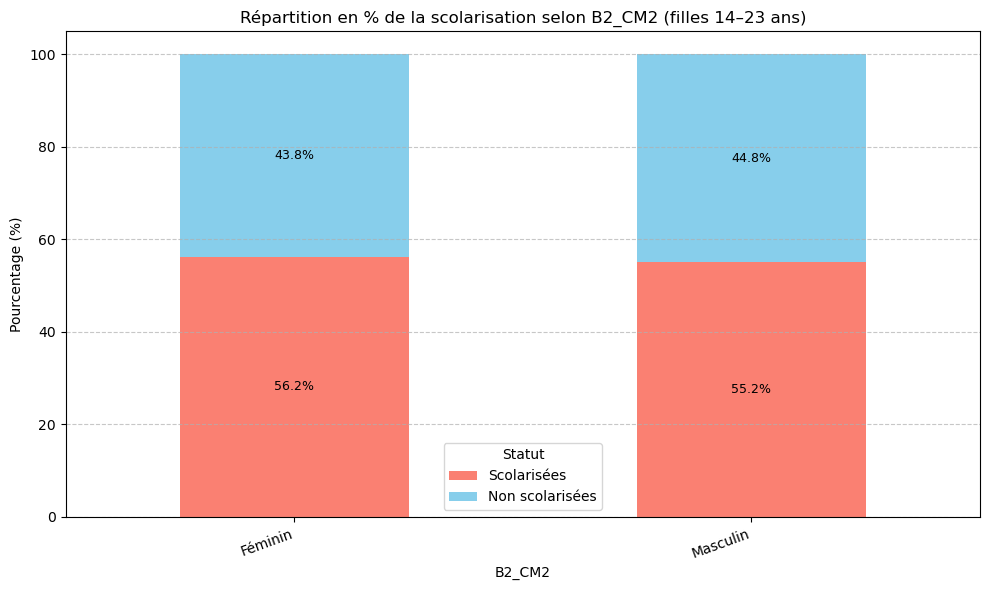

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Modifier ici le nom de la variable à croiser avec 'scole'
variable = 'B2_CM2'  # exemple : A5 = milieu de résidence

# 🔹 Filtrer filles âgées de 14 à 23 ans avec valeurs valides
df_filles = df[
    (df['B2'] == 'Féminin') &
    (df['B4'] >= 11) &
    (df['B4'] <= 23) &
    (df['scole'].notna()) &
    (df[variable].notna())
].copy()

# 🔹 Créer le tableau croisé pondéré
tableau = pd.pivot_table(df_filles,
                         index=variable,
                         columns='scole',
                         values='ipond',
                         aggfunc='sum',
                         fill_value=0)

# 🔹 Renommer les colonnes
tableau = tableau.rename(columns={0: 'Scolarisées', 1: 'Non scolarisées'})

# 🔹 Ajouter colonnes manquantes si besoin
for col in ['Scolarisées', 'Non scolarisées']:
    if col not in tableau.columns:
        tableau[col] = 0

# 🔹 Calculer les % par modalité
tableau = tableau[['Scolarisées', 'Non scolarisées']]
tableau_pct = tableau.div(tableau.sum(axis=1), axis=0) * 100
tableau_pct = tableau_pct.fillna(0).round(1)

# 🔹 Tracer
ax = tableau_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['salmon', 'skyblue'])

# 🔹 Ajouter les % sur les segments
for i, val in enumerate(tableau_pct.index):
    y_scol = tableau_pct.loc[val, 'Scolarisées']
    y_nonscol = tableau_pct.loc[val, 'Non scolarisées']
    if y_scol > 0:
        ax.text(i, y_scol / 2, f"{y_scol:.1f}%", ha='center', va='center', fontsize=9)
    if y_nonscol > 0:
        ax.text(i, y_scol + y_nonscol / 2, f"{y_nonscol:.1f}%", ha='center', va='center', fontsize=9)

# 🔹 Mise en forme
plt.title(f"Répartition en % de la scolarisation selon {variable} (filles 14–23 ans)")
plt.xlabel(variable)
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=20, ha='right')
plt.legend(title="Statut")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


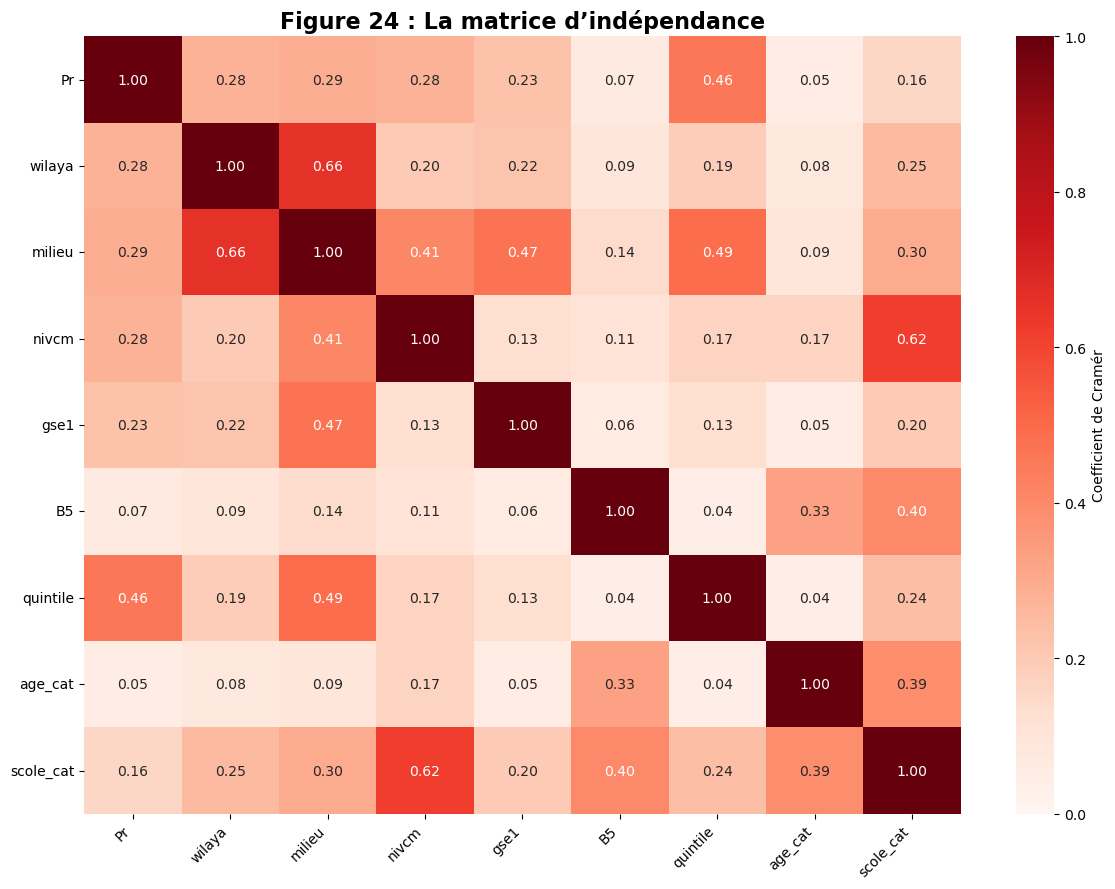

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# 🔹 Fonction pour calculer Cramér V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.empty:
        return np.nan
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# 🔹 Variables issues de ta base
variables = ['Pr', 'wilaya', 'milieu', 'nivcm', 'gse1', 'B5', 'quintile', 'age_cat', 'scole_cat']

# 🔹 Nettoyer les données : garder uniquement les filles 12–23 ans avec données complètes
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')
df_filles = df[(df['B2'] == 'Féminin') & (df['B4'].between(12, 23))][variables].dropna()

# 🔹 Créer la matrice vide
n = len(variables)
cramer_matrix = pd.DataFrame(np.zeros((n, n)), index=variables, columns=variables)

# 🔹 Calculer les coefficients de Cramér V
for i in range(n):
    for j in range(n):
        var1 = variables[i]
        var2 = variables[j]
        if var1 == var2:
            cramer_matrix.loc[var1, var2] = 1.0
        else:
            v = cramers_v(df_filles[var1], df_filles[var2])
            cramer_matrix.loc[var1, var2] = round(v, 2)

# 🔹 Afficher la heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1,
            cbar_kws={"label": "Coefficient de Cramér"})

plt.title("Figure 24 : La matrice d’indépendance", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Vérifier que la variable décile existe (exemple: 'decile')
variable = 'decile1'  # remplace par le nom exact dans ta base si besoin

# 🔹 S'assurer que B4 est numérique
df['B4'] = pd.to_numeric(df['B4'], errors='coerce')

# 🔹 Filtrer filles âgées de 14 à 23 ans avec données valides
df_filles = df[
    (df['B2'] == 'Féminin') &
    df['B4'].between(14, 23) &
    df['scole'].notna() &
    df[variable].notna() &
    df['ipond'].notna()
].copy()

# 🔹 Mapper la variable scole
df_filles['scolarisation'] = df_filles['scole'].map({0: 'Scolarisée', 1: 'Non scolarisée'})

# 🔹 Tableau croisé pondéré
table = pd.pivot_table(df_filles,
                       index=variable,
                       columns='scolarisation',
                       values='ipond',
                       aggfunc='sum',
                       fill_value=0)

# 🔹 Ajouter les colonnes manquantes si absentes
for col in ['Scolarisée', 'Non scolarisée']:
    if col not in table.columns:
        table[col] = 0

# 🔹 Réorganiser l’ordre et calculer les pourcentages
table = table[['Non scolarisée', 'Scolarisée']]
table_pct = table.div(table.sum(axis=1), axis=0) * 100
table_pct = table_pct.fillna(0).round(1)

# 🔹 Trier si tu veux (optionnel)
table_pct = table_pct.sort_index()

# 🔹 Affichage
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#B22222', 'skyblue']  # rouge foncé, bleu

bar_non = ax.bar(table_pct.index.astype(str), table_pct['Non scolarisée'], label='Non scolarisée', color=colors[0])
bar_scol = ax.bar(table_pct.index.astype(str), table_pct['Scolarisée'], bottom=table_pct['Non scolarisée'], label='Scolarisée', color=colors[1])

# 🔹 Ajouter les pourcentages sur les barres
for i, val in enumerate(table_pct.index):
    non = table_pct.loc[val, 'Non scolarisée']
    scol = table_pct.loc[val, 'Scolarisée']
    if non > 0:
        ax.text(i, non / 2, f"{non:.1f}%", ha='center', va='center', fontsize=9, color='white')
    if scol > 0:
        ax.text(i, non + scol / 2, f"{scol:.1f}%", ha='center', va='center', fontsize=9)

# 🔹 Mise en forme
# ax.set_title("Scolarisation selon le décile de pauvreté (filles 14–23 ans)", fontsize=13, weight='bold')
# ax.set_xlabel("Décile")
ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, 105)
ax.set_xticks(range(len(table_pct.index)))
ax.set_xticklabels(table_pct.index.astype(str))
# En dehors de la figure, à droite
ax.legend(title="Statut", loc="upper left", bbox_to_anchor=(1.02, 1))

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


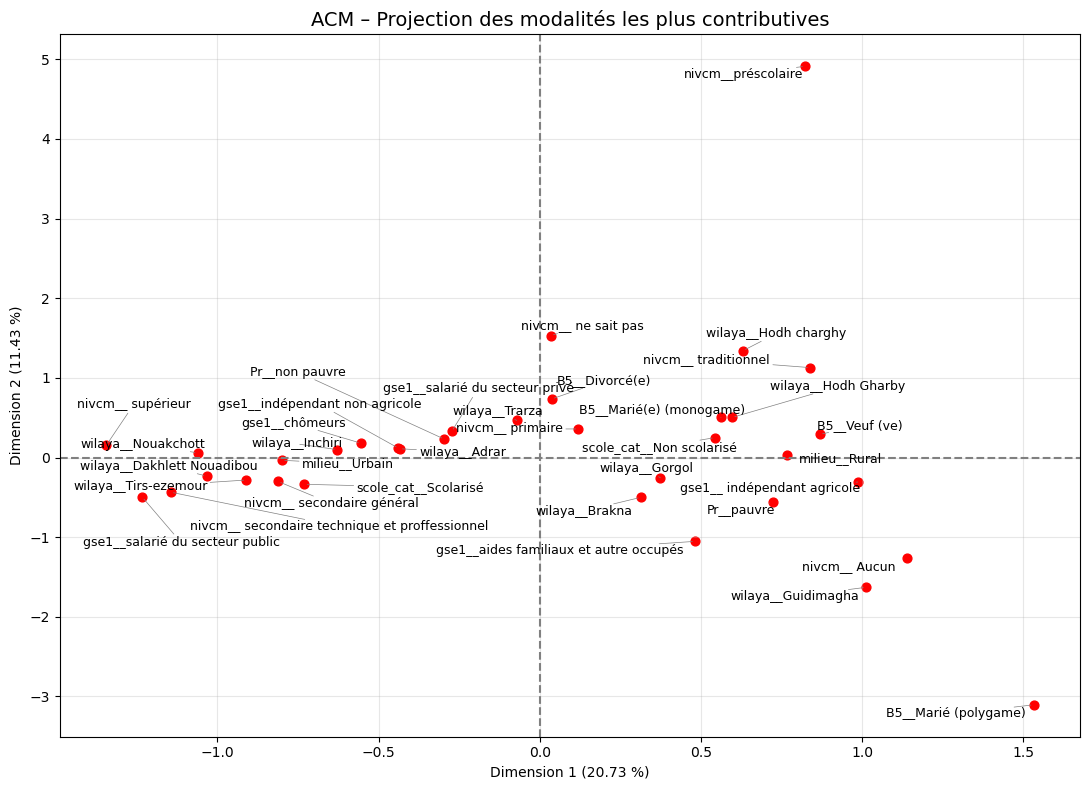

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import prince

# 🔹 Filtrage
# df = pd.read_csv("C:/Users/pc/Downloads/Fusion_1.csv")
df = df[(df["B2"] == "Féminin") & (pd.to_numeric(df["B4"], errors='coerce').between(12, 24))]
variables = ["Pr", "wilaya", "milieu", "nivcm", "gse1", "B5", "scole_cat"]
df_acm = df[variables].dropna().astype(str)

# 🔹 ACM
mca = prince.MCA(n_components=10, random_state=42)
mca = mca.fit(df_acm)

# 🔹 Coordonnées + inertie
mod_coords = mca.column_coordinates(df_acm)
eigvals = mca.eigenvalues_
total_inertia = sum(eigvals)
inertias = [(v / total_inertia) * 100 for v in eigvals]

# 🔹 Sélection des modalités les plus éloignées
mod_coords['distance'] = (mod_coords[0]**2 + mod_coords[1]**2)**0.5
top_modalites = mod_coords.sort_values(by='distance', ascending=False).head(35)

# 🔹 Tracé
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(top_modalites[0], top_modalites[1], color='red', s=40)

# 🔹 Ajouter les étiquettes avec ajustement automatique
texts = []
for i in top_modalites.index:
    x, y = top_modalites.loc[i, 0], top_modalites.loc[i, 1]
    texts.append(ax.text(x, y, i, fontsize=9, ha='right', va='center'))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# 🔹 Mise en page
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.set_title("ACM – Projection des modalités les plus contributives", fontsize=14)
ax.set_xlabel(f"Dimension 1 ({inertias[0]:.2f} %)")
ax.set_ylabel(f"Dimension 2 ({inertias[1]:.2f} %)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


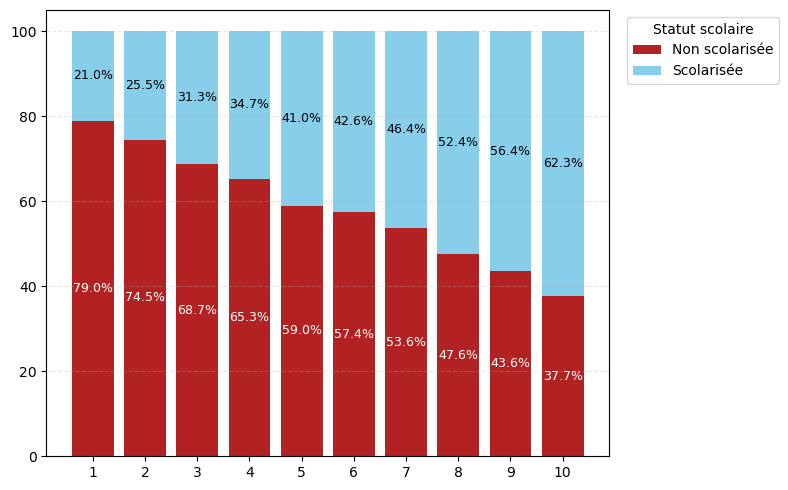

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Charger les données
# df = pd.read_csv("Fusion_1.csv")

# 🔹 Filtrer filles âgées de 14 à 23 ans avec valeurs valides
df_filles = df[
    (df["B2"] == "Féminin") &
    (pd.to_numeric(df["B4"], errors='coerce').between(12, 23)) &
    df["scole"].notna() &
    df["decile1"].notna() &
    df["ipond"].notna()
].copy()

# 🔹 Mapper scole
df_filles["scolarisation"] = df_filles["scole"].map({0: "Scolarisée", 1: "Non scolarisée"})

# 🔹 Tableau croisé pondéré Pr × scole
table = pd.crosstab(
    index=df_filles["decile1"],
    columns=df_filles["scolarisation"],
    values=df_filles["ipond"],
    aggfunc="sum",
    normalize="index"
) * 100
table = table.fillna(0).round(1)

# 🔹 Trier par taux décroissant de non scolarisation
table = table.sort_values(by="Non scolarisée", ascending=False)

# 🔹 Tracer le graphique
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Non scolarisée": "#B22222", "Scolarisée": "skyblue"}

bar1 = ax.bar(table.index.astype(str), table["Non scolarisée"], color=colors["Non scolarisée"], label="Non scolarisée")
bar2 = ax.bar(table.index.astype(str), table["Scolarisée"], bottom=table["Non scolarisée"], color=colors["Scolarisée"], label="Scolarisée")

# 🔹 Ajouter les % sur les barres
for i, idx in enumerate(table.index):
    ns = table.loc[idx, "Non scolarisée"]
    sc = table.loc[idx, "Scolarisée"]
    ax.text(i, ns / 2, f"{ns:.1f}%", ha="center", va="center", color="white", fontsize=9)
    ax.text(i, ns + sc / 2, f"{sc:.1f}%", ha="center", va="center", fontsize=9)

# 🔹 Mise en forme
# ax.set_title("Scolarisation des filles (14–23 ans) selon la pauvreté (Pr)", fontsize=13)
# ax.set_xlabel("Statut de pauvreté (0 = Non pauvre, 1 = Pauvre)")
# ax.set_ylabel("Pourcentage (%)")
ax.set_ylim(0, 105)
ax.legend(title="Statut scolaire", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


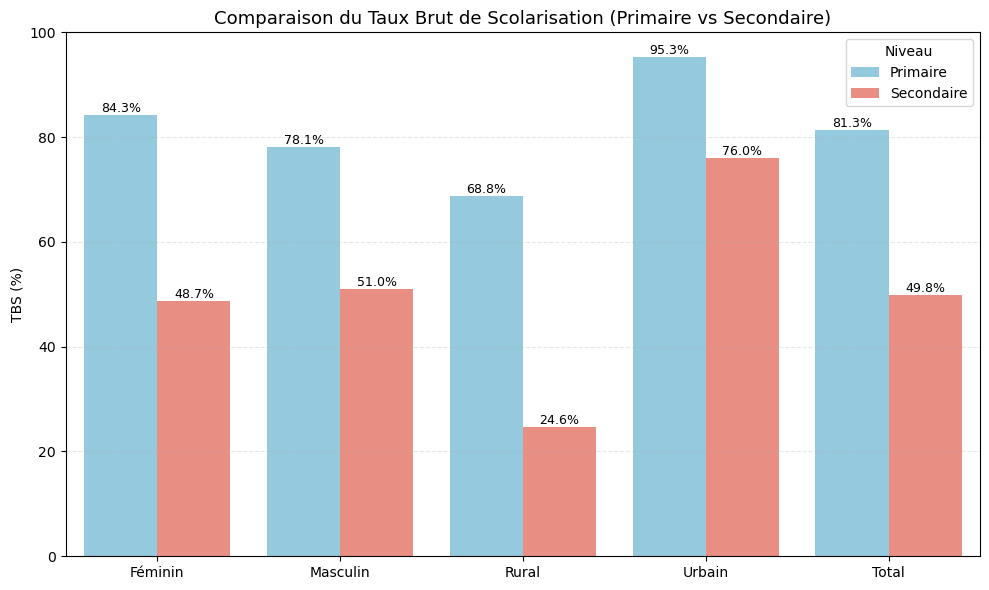

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 TBS secondaire extrait du tableau
tbs_secondaire = {
    'Masculin': 51.0,
    'Féminin': 48.7,
    'Urbain': 76.0,
    'Rural': 24.6,
    'Total': 49.8
}

# 🔹 Calculer TBSp moyen selon sexe, milieu, total
colonnes = ['B2', 'milieu']
resultats = []

# 🔹 TBS Primaire par sexe et milieu
for var in colonnes:
    tbsp_moyen = df.groupby(var)['TBSp'].mean().round(1)
    for k, v in tbsp_moyen.items():
        resultats.append({'Groupe': str(k), 'Niveau': 'Primaire', 'TBS': v})

# 🔹 TBS Primaire au niveau national
total_tbsp = df['TBSp'].mean().round(1)
resultats.append({'Groupe': 'Total', 'Niveau': 'Primaire', 'TBS': total_tbsp})

# 🔹 Ajouter les TBS secondaire
for k, v in tbs_secondaire.items():
    resultats.append({'Groupe': k, 'Niveau': 'Secondaire', 'TBS': v})

# 🔹 DataFrame pour graphique
df_plot = pd.DataFrame(resultats)
df_plot = df_plot[df_plot['Groupe'].isin(['Masculin', 'Féminin', 'Urbain', 'Rural', 'Total'])]

# 🔹 Tracer
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x='Groupe', y='TBS', hue='Niveau', palette=['skyblue', 'salmon'])

# 🔹 Ajouter % sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title("Comparaison du Taux Brut de Scolarisation (Primaire vs Secondaire)", fontsize=13)
plt.xlabel("")
plt.ylabel("TBS (%)")
plt.ylim(0, 100)
plt.legend(title="Niveau")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


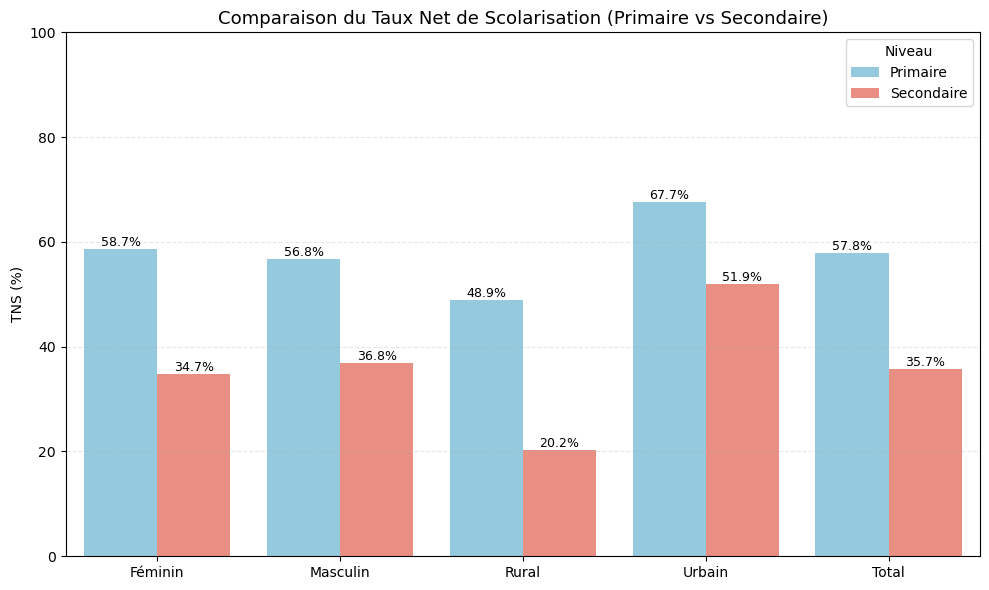

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 TNS secondaire depuis le tableau image
tns_secondaire = {
    'Masculin': 36.8,
    'Féminin': 34.7,
    'Urbain': 51.9,
    'Rural': 20.2,
    'Total': 35.7
}

# 🔹 Calculer TNS primaire depuis la base
colonnes = ['B2', 'milieu']
resultats = []

# 🔹 TNS Primaire par sexe et milieu
for var in colonnes:
    tnsp_moyen = df.groupby(var)['TNSp'].mean().round(1)
    for k, v in tnsp_moyen.items():
        resultats.append({'Groupe': str(k), 'Niveau': 'Primaire', 'TNS': v})

# 🔹 Moyenne nationale
total_tnsp = df['TNSp'].mean().round(1)
resultats.append({'Groupe': 'Total', 'Niveau': 'Primaire', 'TNS': total_tnsp})

# 🔹 Ajouter les TNS secondaire
for k, v in tns_secondaire.items():
    resultats.append({'Groupe': k, 'Niveau': 'Secondaire', 'TNS': v})

# 🔹 Créer DataFrame pour le graphique
df_plot = pd.DataFrame(resultats)
df_plot = df_plot[df_plot['Groupe'].isin(['Masculin', 'Féminin', 'Urbain', 'Rural', 'Total'])]

# 🔹 Tracer
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x='Groupe', y='TNS', hue='Niveau', palette=['skyblue', 'salmon'])

# 🔹 Ajouter % sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title("Comparaison du Taux Net de Scolarisation (Primaire vs Secondaire)", fontsize=13)
plt.xlabel("")
plt.ylabel("TNS (%)")
plt.ylim(0, 100)
plt.legend(title="Niveau", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
pip install geopandas matplotlib pandas


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.2 MB 5.6 MB/s eta 0:00:04
   ---- ----------------------------------- 2.1/19.2 MB 5.1 MB/s eta 0:00:04
   ----- ---------------------------------- 2.6/19.2 MB 5.4 MB/s eta 0:00:04
   ------- -------------------------------- 3.7/19.2 MB 4.4 MB/s eta 0:00:04
   --------- ------------------------------ 4.5/19.2 MB 4.3 MB/s eta 0:00:04
   ---------- ----------------------------- 5.2/19.2 MB 4.1 MB/s eta 0:00:04
   ------------ --------------------------- 6.0/19.2 MB 4.1 MB/s eta 0:00:04
   ------------- -------------------------- 6.6/19.2 MB 3.8 MB/s eta 0:00:04
   --------------- ------------------------ 7.3/19.2 MB 3.8 MB/s eta 0:00:04
   ---------------- ----------------------- 7.9/19.2 MB 3.7 MB/s eta 0:00:04
   ----------------- ---------------------- 8.4/19.2 MB 3.6 MB/s eta 0:00:03
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


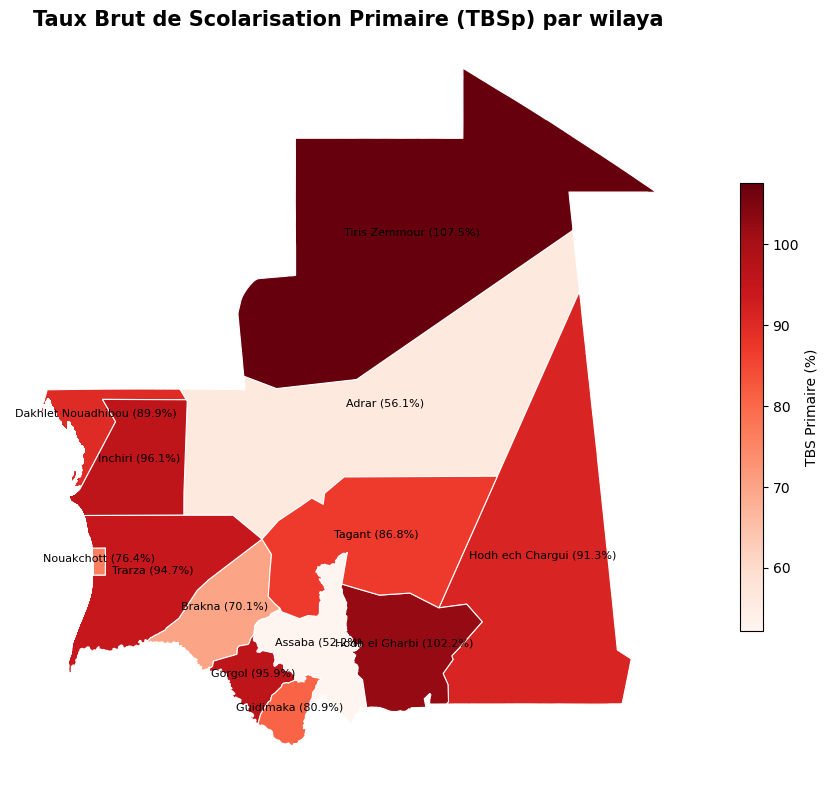

In [17]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Charger le shapefile
shapefile_path = r"C:/Users/pc/Downloads/gadm41_MRT_shp (1)/gadm41_MRT_1.shp"
gdf = gpd.read_file(shapefile_path)

# 🔹 Liste des taux depuis ton image
data = {
    'wilaya': ['Adrar', 'Assaba', 'Brakna', 'Dakhlet Nouadhibou', 'Gorgol', 'Guidimaka', 'Hodh ech Chargui', 'Hodh el Gharbi', 'Inchiri', 'Nouakchott', 'Tagant', 'Tiris Zemmour', 'Trarza'],
    'TBSp': [
        56.14, 52.22, 70.08, 89.90, 95.90, 80.91,
        91.29, 102.16, 96.12, 76.40, 86.82,
        107.52, 94.65
    ]
}
df_tbsp = pd.DataFrame(data)

# 🔹 Vérifier et adapter les noms pour correspondre au shapefile
# renommer = {
#     "Hodh ech Chargui": "Hodh El Charbi",
#     "Hodh el Gharbi": "Hodh El Gharbi",
#     "Dakhlet-Nouadhibou": "Dakhlet Nouadhibou",
#     "Guidimaka": "Guidimagha",
#     "Tiris Zemmour": "Tiris-Zemmour",
#     "Nouakchott": "Nouakchott",
#     "Inchiri": "Inchiri"
# }
# df_tbsp['wilaya'] = df_tbsp['wilaya'].replace(renommer)

# 🔹 Ajouter la colonne 'wilaya' dans le GeoDataFrame
gdf['wilaya'] = gdf['NAME_1']

# 🔹 Fusion avec les taux TBSp
merged = gdf.merge(df_tbsp, on='wilaya')

# 🔹 Tracer la carte
fig, ax = plt.subplots(figsize=(11, 8))
merged.plot(
    column='TBSp',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=True,
    legend_kwds={'label': "TBS Primaire (%)", 'shrink': 0.6}
)

# 🔹 Ajouter étiquettes de wilaya et taux
for idx, row in merged.iterrows():
    plt.annotate(
        text=f"{row['wilaya']} ({round(row['TBSp'],1)}%)",
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        fontsize=8,
        color='black'
    )

# 🔹 Mise en forme
ax.set_title("Taux Brut de Scolarisation Primaire (TBSp) par wilaya", fontsize=15, weight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


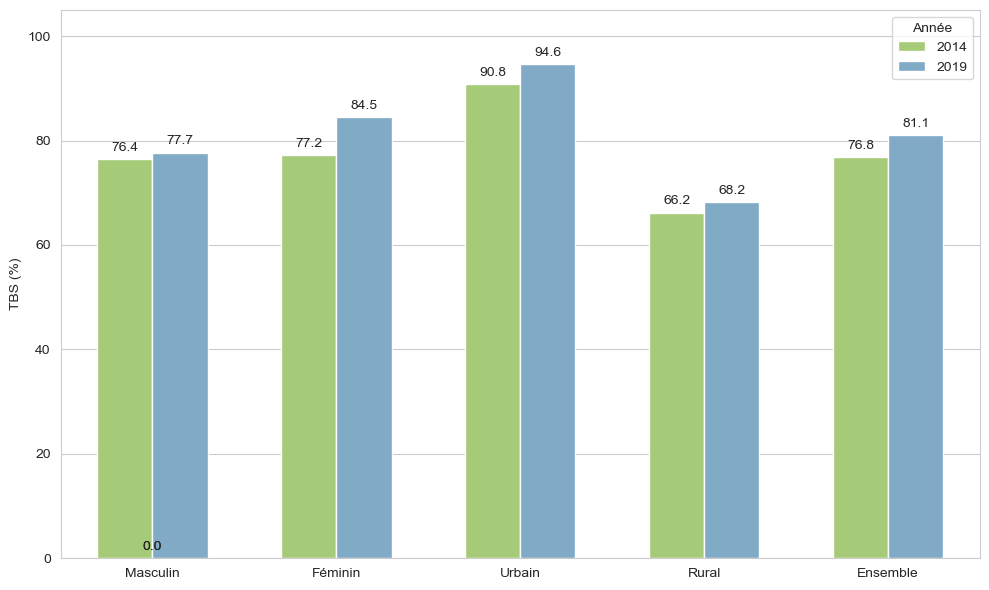

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Données du graphique
data = {
    'Groupe': ['Masculin', 'Féminin', 'Urbain', 'Rural', 'Ensemble'],
    '2014': [76.4, 77.2, 90.8, 66.2, 76.8],
    '2019': [77.7, 84.5, 94.6, 68.2, 81.1]
}

# 🔹 Créer un DataFrame
df = pd.DataFrame(data)

# 🔹 Transformation en format long (long format)
df_melted = df.melt(id_vars='Groupe', var_name='Année', value_name='TBS')

# 🔹 Tracer le graphique avec seaborn
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

barplot = sns.barplot(
    data=df_melted,
    x='Groupe',
    y='TBS',
    hue='Année',
    palette=['#a6d96a', '#74add1'],  # Vert clair pour 2014, bleu pour 2019
    width=0.6
)

# 🔹 Ajouter les pourcentages sur les barres
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.1f}',
                     (p.get_x() + p.get_width() / 2., height + 1),
                     ha='center', va='bottom', fontsize=10)

# 🔹 Titres et axes
# plt.title("Taux brut de scolarisation au fondamental en 2014 et 2019", fontsize=14, weight='bold')
plt.ylim(0, 105)
plt.ylabel("TBS (%)")
plt.xlabel("")
plt.legend(title="Année", loc='upper right')
plt.tight_layout()
plt.show()


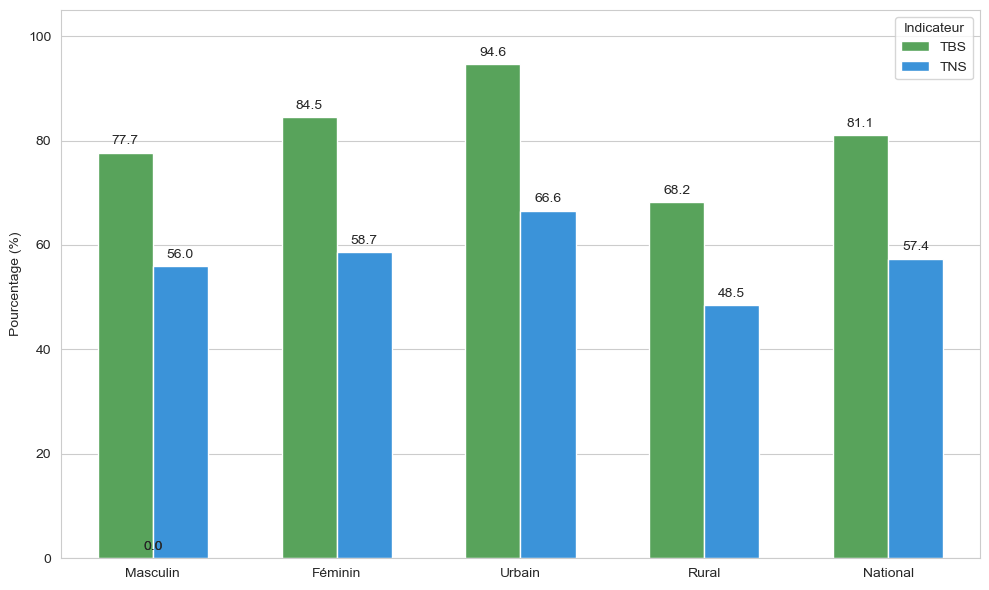

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Données
data = {
    'Groupe': ['Masculin', 'Féminin', 'Urbain', 'Rural', 'National'],
    'TBS': [77.7, 84.5, 94.6, 68.2, 81.1],
    'TNS': [56.0, 58.7, 66.6, 48.5, 57.4]
}

# 🔹 Transformation en format long
df = pd.DataFrame(data)
df_melted = df.melt(id_vars='Groupe', var_name='Indicateur', value_name='Valeur')

# 🔹 Tracer
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

barplot = sns.barplot(
    data=df_melted,
    x='Groupe',
    y='Valeur',
    hue='Indicateur',
    palette=['#4CAF50', '#2196F3'],  # Vert pour TBS, Bleu pour TNS
    width=0.6
)

# 🔹 Ajouter les pourcentages sur les barres
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.1f}',
                     (bar.get_x() + bar.get_width() / 2., height + 1),
                     ha='center', va='bottom', fontsize=10)

# 🔹 Mise en forme
# plt.title("TBS et TNS du primaire en 2019", fontsize=14, weight='bold')
plt.ylabel("Pourcentage (%)")
plt.xlabel("")
plt.ylim(0, 105)
plt.legend(title="Indicateur", loc='upper right')
plt.tight_layout()
plt.show()


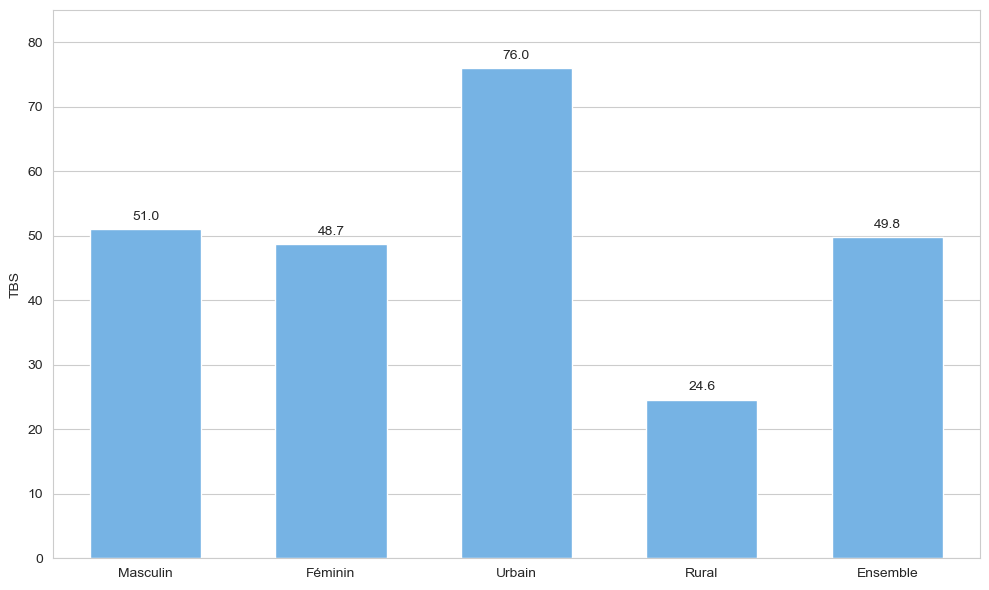

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Données pour 2019 uniquement
data = {
    'Groupe': ['Masculin', 'Féminin', 'Urbain', 'Rural', 'Ensemble'],
    'TBS': [51.0, 48.7, 76.0, 24.6, 49.8]
}

# 🔹 DataFrame
df = pd.DataFrame(data)

# 🔹 Tracer
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

barplot = sns.barplot(
    data=df,
    x='Groupe',
    y='TBS',
    color='#64B5F6',  # bleu doux
    width=0.6
)

# 🔹 Ajouter les % au-dessus
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.1f}',
                     (bar.get_x() + bar.get_width() / 2., height + 1),
                     ha='center', va='bottom', fontsize=10)

# 🔹 Mise en forme
# plt.ylabel("Taux Brut de Scolarisation (%)")
plt.xlabel("")
plt.ylim(0, 85)
# plt.title("TBS au secondaire en 2019", fontsize=14, weight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


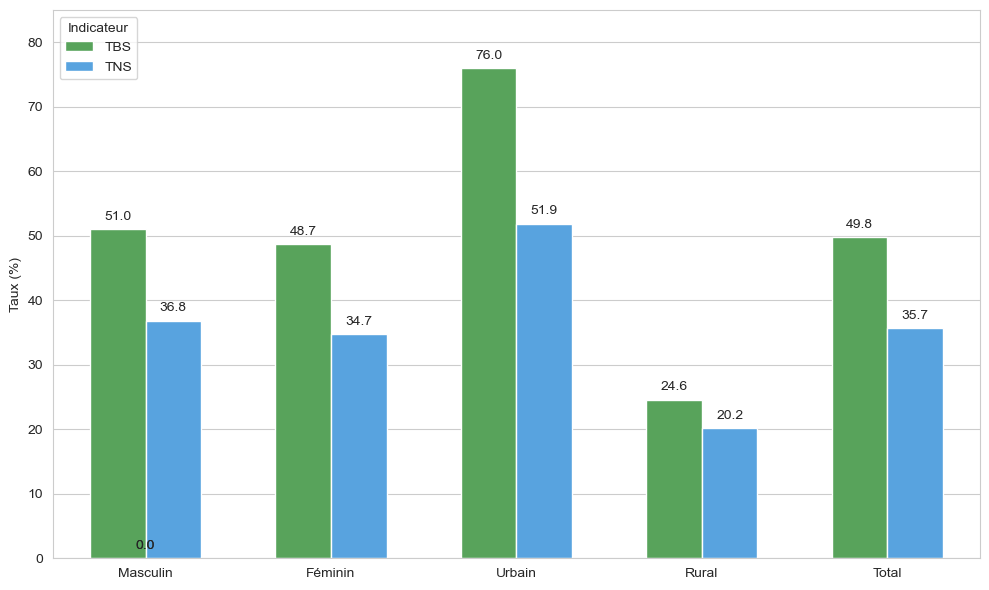

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Données extraites du tableau (sans wilayas)
data = {
    'Groupe': ['Masculin', 'Féminin', 'Urbain', 'Rural', 'Total'],
    'TBS': [51.0, 48.7, 76.0, 24.6, 49.8],
    'TNS': [36.8, 34.7, 51.9, 20.2, 35.7]
}

# 🔹 Mise en format long
df = pd.DataFrame(data)
df_melted = df.melt(id_vars='Groupe', var_name='Type', value_name='Taux')

# 🔹 Tracer
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

palette = {'TBS': '#4CAF50', 'TNS': '#42A5F5'}  # vert et bleu

barplot = sns.barplot(
    data=df_melted,
    x='Groupe',
    y='Taux',
    hue='Type',
    palette=palette,
    width=0.6
)

# 🔹 Ajouter les valeurs
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(f'{height:.1f}',
                     (bar.get_x() + bar.get_width() / 2., height + 1),
                     ha='center', va='bottom', fontsize=10)

# 🔹 Mise en forme
# plt.title("TBS et TNS au secondaire en 2019 selon le sexe et le milieu", fontsize=14, weight='bold')
plt.ylabel("Taux (%)")
plt.xlabel("")
plt.ylim(0, 85)
plt.legend(title="Indicateur", loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


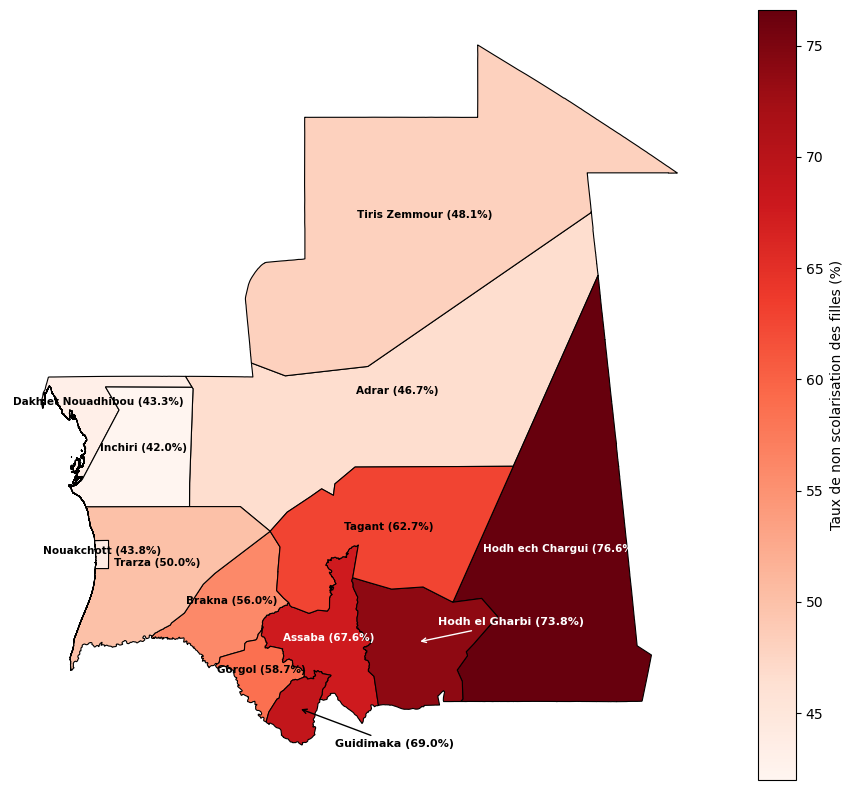

In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Charger le shapefile
shapefile_path = "C:/Users/pc/Downloads/gadm41_MRT_shp (1)/gadm41_MRT_1.shp"
gdf = gpd.read_file(shapefile_path)

# 🔹 Taux de non scolarisation corrigés
non_sco_data = {
    'wilaya': [
        'Hodh ech Chargui', 'Hodh el Gharbi', 'Guidimaka', 'Assaba', 'Tagant',
        'Gorgol', 'Brakna', 'Trarza', 'Inchiri', 'Adrar', 'Nouakchott',
        'Tiris Zemmour', 'Dakhlet Nouadhibou'
    ],
    'non_scolarisation': [76.6, 73.8, 69.0, 67.6, 62.7,
                          58.7, 56.0, 50.0, 42.0, 46.7,
                          43.8, 48.1, 43.3]
}
df_non_sco = pd.DataFrame(non_sco_data)

# 🔹 Fusion
gdf['wilaya'] = gdf['NAME_1']
carte = gdf.merge(df_non_sco, on='wilaya', how='left')

# 🔹 Tracer carte
fig, ax = plt.subplots(figsize=(10, 8))
carte.plot(
    column='non_scolarisation',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Taux de non scolarisation des filles (%)"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Données manquantes"}
)

# ✅ Ajouter les étiquettes avec décalage
for idx, row in carte.dropna(subset=["non_scolarisation"]).iterrows():
    taux = row['non_scolarisation']
    nom = row['wilaya']
    color = 'white' if taux >= 65 else 'black'
    x, y = row.geometry.centroid.x, row.geometry.centroid.y

    # 🔸 Cas particuliers avec décalage :
    if nom == "Guidimaka":
        ax.annotate(
            f"{nom} ({taux:.1f}%)",
            xy=(x, y), xytext=(x + 0.7, y - 0.7),
            ha='left', fontsize=8, color='black', weight='bold',
            arrowprops=dict(arrowstyle='->', color='black')
        )
    elif nom == "Hodh el Gharbi":
        ax.annotate(
            f"{nom} ({taux:.1f}%)",
            xy=(x, y), xytext=(x + 0.4, y + 0.3),
            ha='left', fontsize=8, color='white', weight='bold',
            arrowprops=dict(arrowstyle='->', color='white')
        )
    # elif nom == "Assaba":
    #     ax.annotate(
    #         f"{nom} ({taux:.1f}%)",
    #         xy=(x, y), xytext=(x - 0.3, y - 0.5),
    #         ha='center', fontsize=8, color='white', weight='bold',
    #         arrowprops=dict(arrowstyle='->', color='white')
    #     )
    else:
        ax.annotate(
            f"{nom} ({taux:.1f}%)",
            xy=(x, y),
            ha='center',
            fontsize=7.5,
            color=color,
            weight='bold'
        )

# plt.title("Carte du taux de non scolarisation des filles par wilaya", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


In [17]:
['Adrar', 'Assaba', 'Brakna', 'Dakhlet Nouadhibou', 'Gorgol', 'Guidimaka', 'Hodh ech Chargui', 'Hodh el Gharbi', 'Inchiri', 'Nouakchott', 'Tagant', 'Tiris Zemmour', 'Trarza'],
    'TBSp': 

['Hodh ech Chargui', 'Hodh el Gharbi', 'Guidimaka', 'Assaba', 'Tagant',
               'Gorgol', 'Brakna', 'Trarza', 'Inchiri', 'Adrar', 'Nouakchott',
               'Tiris Zemmour', 'Dakhlet Nouadhibou']

IndentationError: unexpected indent (2447413701.py, line 2)

In [30]:
print(df[['B2', 'age_cat']])

KeyError: "['age_cat'] not in index"